# **1. Perkenalan Dataset**

Dataset yang digunakan dalam eksperimen ini adalah **Cardiovascular Disease Dataset** yang diperoleh dari Kaggle.

Dataset ini berisi data medis pasien yang digunakan untuk memprediksi apakah seseorang memiliki penyakit kardiovaskular atau tidak.

**Fitur-fitur dalam dataset:**
- `age`: Usia pasien (dalam hari, akan dikonversi ke tahun)
- `gender`: Jenis kelamin (1 = perempuan, 2 = laki-laki)
- `height`: Tinggi badan (cm)
- `weight`: Berat badan (kg)
- `ap_hi`: Tekanan darah sistolik
- `ap_lo`: Tekanan darah diastolik
- `cholesterol`: Tingkat kolesterol (1=normal, 2=di atas normal, 3=jauh di atas normal)
- `gluc`: Tingkat glukosa (1=normal, 2=di atas normal, 3=jauh di atas normal)
- `smoke`: Apakah merokok (0=tidak, 1=ya)
- `alco`: Apakah mengonsumsi alkohol (0=tidak, 1=ya)
- `active`: Apakah aktif secara fisik (0=tidak, 1=ya)
- `cardio`: Target — ada/tidaknya penyakit kardiovaskular (0=tidak, 1=ya)

**Tujuan Eksperimen:**
Membangun model klasifikasi biner untuk memprediksi apakah seorang pasien memiliki penyakit kardiovaskular (`cardio` = 1) atau tidak (`cardio` = 0).

**Sumber:** [Kaggle - Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)

# **2. Import Library**

Pada tahap ini, kita mengimpor beberapa pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

print('Library successfully imported.')

Library successfully imported.


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset Cardiovascular Disease ke dalam notebook. Dataset ini menggunakan titik koma (`;`) sebagai separator.

In [2]:
# Load dataset
df = pd.read_csv('cardio_raw/cardio_train.csv', sep=';')

# Display basic info
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Informasi tipe data dan missing values
print('--- Dataset Info ---')
df.info()
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

--- Missing Values ---
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke       

In [4]:
# Distribusi target
print('--- Target Distribution (cardio) ---')
print(df['cardio'].value_counts())
print(f'\nPersentase kelas positif (penyakit kardiovaskular): {df["cardio"].mean()*100:.2f}%')

--- Target Distribution (cardio) ---
cardio
0    35021
1    34979
Name: count, dtype: int64

Persentase kelas positif (penyakit kardiovaskular): 49.97%


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset, termasuk distribusi fitur, korelasi antar variabel, dan pola yang relevan.

In [5]:
# Statistik deskriptif
print('--- Descriptive Statistics ---')
df.describe()

--- Descriptive Statistics ---


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


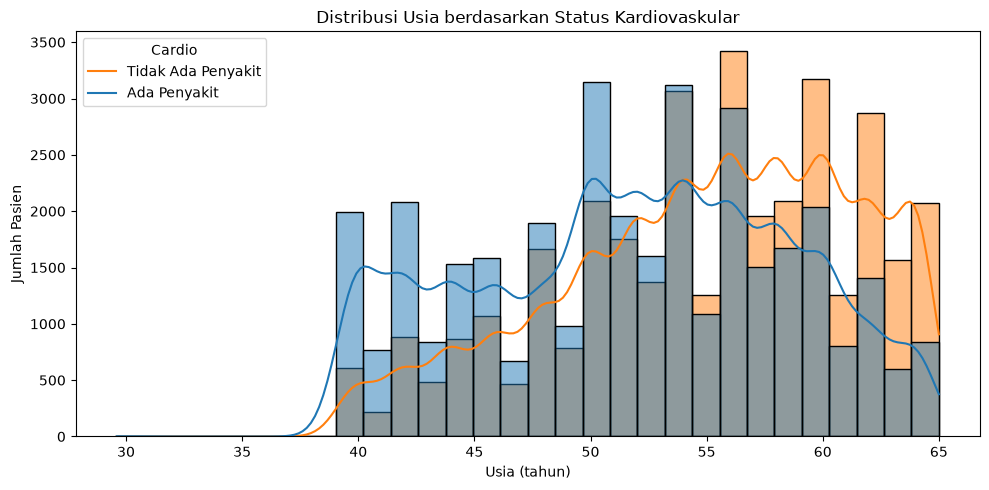

In [6]:
# Konversi age dari hari ke tahun untuk visualisasi yang lebih intuitif
df_eda = df.copy()
df_eda['age_years'] = (df_eda['age'] / 365).round(1)

# Distribusi usia
plt.figure(figsize=(10, 5))
sns.histplot(data=df_eda, x='age_years', hue='cardio', bins=30, kde=True)
plt.title('Distribusi Usia berdasarkan Status Kardiovaskular')
plt.xlabel('Usia (tahun)')
plt.ylabel('Jumlah Pasien')
plt.legend(title='Cardio', labels=['Tidak Ada Penyakit', 'Ada Penyakit'])
plt.tight_layout()
plt.show()

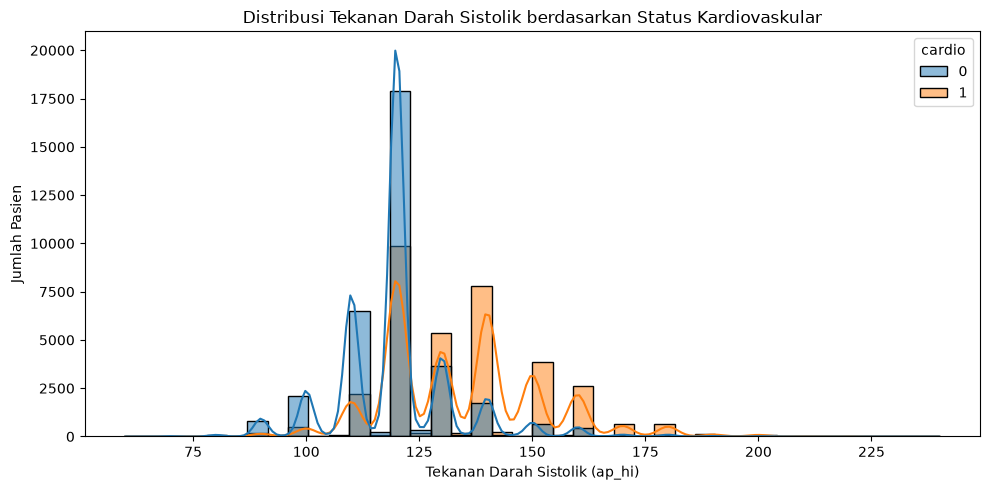

In [7]:
# Distribusi tekanan darah sistolik (ap_hi)
plt.figure(figsize=(10, 5))
# Filter outlier ekstrem untuk visualisasi
df_vis = df_eda[(df_eda['ap_hi'] >= 60) & (df_eda['ap_hi'] <= 250)]
sns.histplot(data=df_vis, x='ap_hi', hue='cardio', bins=40, kde=True)
plt.title('Distribusi Tekanan Darah Sistolik berdasarkan Status Kardiovaskular')
plt.xlabel('Tekanan Darah Sistolik (ap_hi)')
plt.ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()

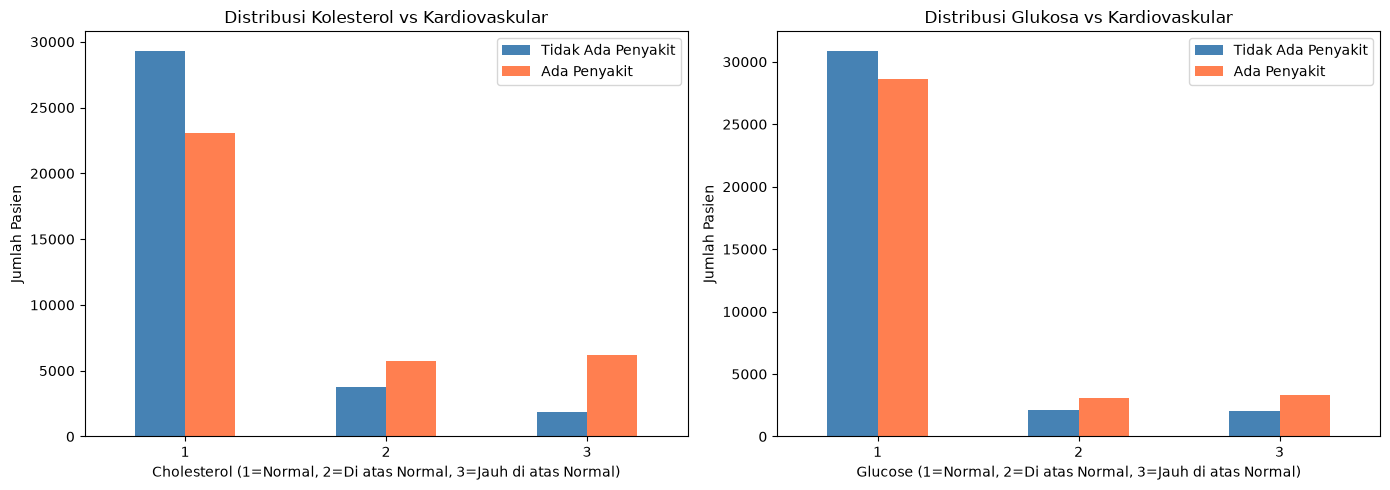

In [8]:
# Distribusi kolesterol dan glukosa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cholesterol
cholesterol_counts = df_eda.groupby(['cholesterol', 'cardio']).size().unstack()
cholesterol_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Distribusi Kolesterol vs Kardiovaskular')
axes[0].set_xlabel('Cholesterol (1=Normal, 2=Di atas Normal, 3=Jauh di atas Normal)')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].legend(['Tidak Ada Penyakit', 'Ada Penyakit'])
axes[0].tick_params(axis='x', rotation=0)

# Glucose
gluc_counts = df_eda.groupby(['gluc', 'cardio']).size().unstack()
gluc_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Distribusi Glukosa vs Kardiovaskular')
axes[1].set_xlabel('Glucose (1=Normal, 2=Di atas Normal, 3=Jauh di atas Normal)')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].legend(['Tidak Ada Penyakit', 'Ada Penyakit'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

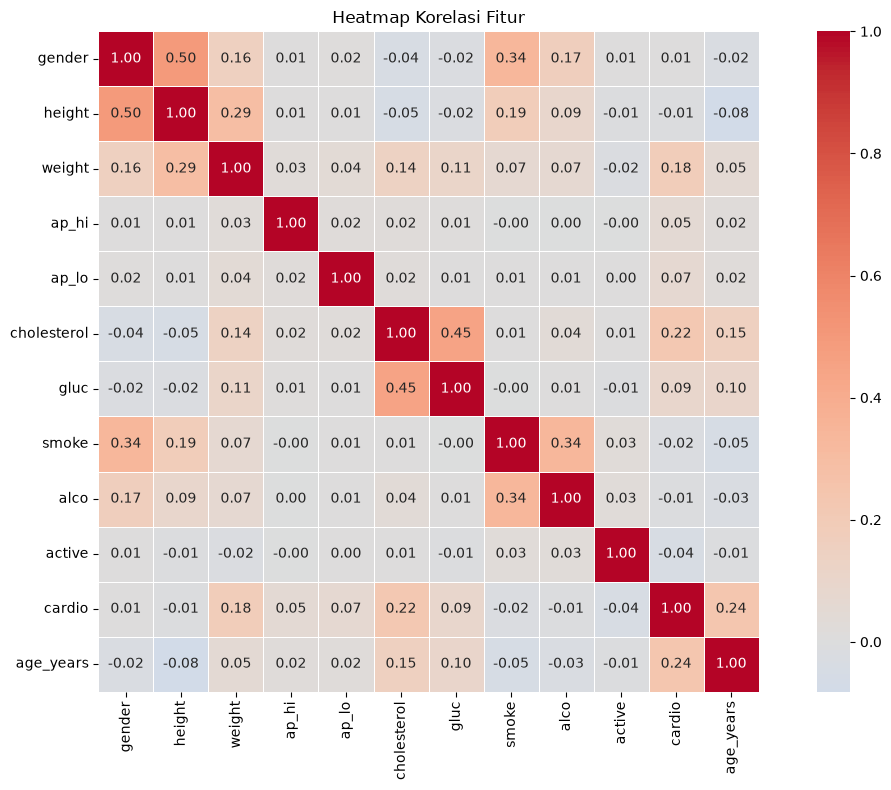

In [9]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
df_corr = df_eda.drop(['id', 'age'], axis=1)  # Gunakan age_years
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

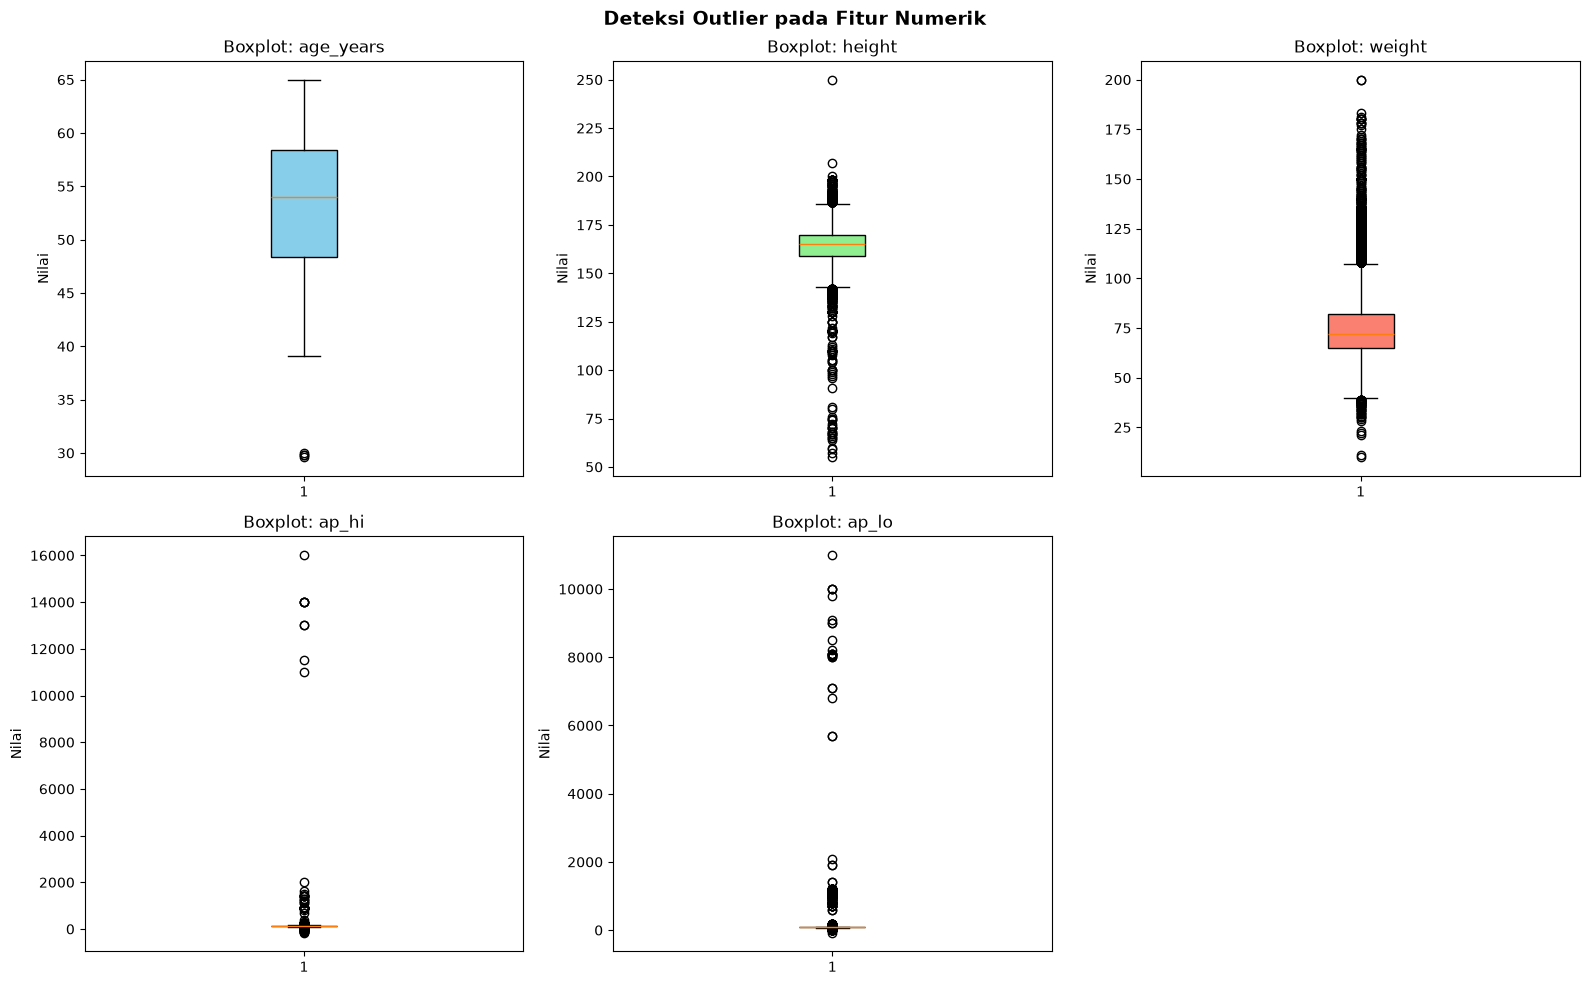

Outlier terlihat jelas pada ap_hi dan ap_lo — akan ditangani dengan IQR Capping.


In [10]:
# Boxplot untuk deteksi outlier pada fitur numerik utama
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold']

for i, (feat, color) in enumerate(zip(num_features, colors)):
    row, col = divmod(i, 3)
    axes[row][col].boxplot(df_eda[feat].dropna(), patch_artist=True,
                           boxprops=dict(facecolor=color))
    axes[row][col].set_title(f'Boxplot: {feat}')
    axes[row][col].set_ylabel('Nilai')

# Hapus subplot kosong
axes[1][2].axis('off')

plt.suptitle('Deteksi Outlier pada Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Outlier terlihat jelas pada ap_hi dan ap_lo — akan ditangani dengan IQR Capping.')

# **5. Data Preprocessing**

Berdasarkan hasil EDA, kita akan melakukan langkah-langkah preprocessing berikut:
1. Drop kolom `id` (tidak relevan sebagai fitur)
2. Konversi `age` dari hari ke tahun
3. Hapus data duplikat
4. Penanganan outlier menggunakan IQR Capping
5. Train-Test Split
6. Standarisasi fitur numerik kontinu

In [11]:
# 1. Drop kolom id
df = df.drop('id', axis=1)
print('Kolom id berhasil di-drop. Shape:', df.shape)

Kolom id berhasil di-drop. Shape: (70000, 12)


In [12]:
# 2. Konversi age dari hari ke tahun
df['age'] = (df['age'] / 365).round(1)
print('Konversi age selesai. Range usia:', df['age'].min(), '-', df['age'].max(), 'tahun')

Konversi age selesai. Range usia: 29.6 - 65.0 tahun


In [13]:
# 3. Hapus data duplikat
initial_len = len(df)
df = df.drop_duplicates()
print(f'Data duplikat dihapus: {initial_len - len(df)} baris. Shape baru: {df.shape}')

Data duplikat dihapus: 665 baris. Shape baru: (69335, 12)


In [14]:
# 4. Penanganan Outlier dengan IQR Capping
# Kolom biner/ordinal tidak di-cap
binary_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
num_cols = df.select_dtypes(include=[np.number]).columns.difference(binary_cols)

print('Fitur yang akan di-cap:', list(num_cols))
print('\nSebelum IQR Capping:')
print(df[num_cols].describe().loc[['min', 'max']])

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print('\nSetelah IQR Capping:')
print(df[num_cols].describe().loc[['min', 'max']])

Fitur yang akan di-cap: ['age', 'ap_hi', 'ap_lo', 'height', 'weight']

Sebelum IQR Capping:
      age    ap_hi    ap_lo  height  weight
min  29.6   -150.0    -70.0    55.0    10.0
max  65.0  16020.0  11000.0   250.0   200.0

Setelah IQR Capping:
      age  ap_hi  ap_lo  height  weight
min  33.4   90.0   65.0   142.5    39.5
max  65.0  170.0  105.0   186.5   107.5


In [15]:
# 5. Train-Test Split (80% train, 20% test)
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nDistribusi target training: {y_train.value_counts().to_dict()}')
print(f'Distribusi target test: {y_test.value_counts().to_dict()}')

Training set: (55468, 11)
Test set: (13867, 11)

Distribusi target training: {1: 27858, 0: 27610}
Distribusi target test: {1: 6965, 0: 6902}


In [16]:
# 6. Standarisasi fitur numerik kontinu
scale_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print('Standarisasi selesai.')
print('\nContoh nilai setelah scaling (5 baris pertama):')
print(X_train_scaled[scale_cols].head())

Standarisasi selesai.

Contoh nilai setelah scaling (5 baris pertama):
            age    height    weight     ap_hi     ap_lo
19343  0.729857  0.712185 -0.668017 -1.023231 -1.296517
10468  0.345834 -1.197950 -0.222312  2.018624  1.994580
21632  0.035661 -1.325292 -0.890869 -0.414860 -0.199484
69169  0.936639 -1.579977 -1.039437  0.193511 -0.199484
4552   1.084341 -1.325292  0.149109  0.193511 -0.199484


In [17]:
# 7. Gabungkan fitur dan target, lalu simpan output
train_processed = pd.concat([X_train_scaled, y_train], axis=1)
test_processed = pd.concat([X_test_scaled, y_test], axis=1)

output_dir = 'cardio_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, 'train_processed.csv')
test_path = os.path.join(output_dir, 'test_processed.csv')
scaler_path = os.path.join(output_dir, 'scaler.joblib')

train_processed.to_csv(train_path, index=False)
test_processed.to_csv(test_path, index=False)
joblib.dump(scaler, scaler_path)

print(f'Data latih disimpan: {train_path} | Shape: {train_processed.shape}')
print(f'Data uji disimpan: {test_path} | Shape: {test_processed.shape}')
print(f'Scaler disimpan: {scaler_path}')
print('\nPreprocessing selesai!')

Data latih disimpan: cardio_preprocessing/train_processed.csv | Shape: (55468, 12)
Data uji disimpan: cardio_preprocessing/test_processed.csv | Shape: (13867, 12)
Scaler disimpan: cardio_preprocessing/scaler.joblib

Preprocessing selesai!
